Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing dataset

In [2]:
import pandas as pd
df_2= pd.read_csv('/content/drive/training_v2.csv')
len(df_2.columns)

186

**Renaming and Labelling the Varibales**

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --------------------------
# STEP 1: Load data
# --------------------------
df = pd.read_csv('/content/drive/MyDrive/training_v2.csv')
# Selected variables based on dictionary analysis
import pandas as pd

# Define the selected variables and their corresponding short labels
selected_variables = {
    'age': 'Age',
    'bmi': 'BMI',
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'elective_surgery': 'Elective Surgery',
    'icu_admit_source': 'ICU Admit Source',
    'icu_type': 'ICU Type',
    'pre_icu_los_days': 'Pre-ICU LOS',
    'apache_2_diagnosis': 'APACHE II Diagnosis',
    'apache_3j_diagnosis': 'APACHE III Diagnosis',
    'apache_post_operative': 'Post-Operative',
    'arf_apache': 'Acute Renal Failure',
    'gcs_eyes_apache': 'GCS Eyes',
    'gcs_motor_apache': 'GCS Motor',
    'gcs_verbal_apache': 'GCS Verbal',
    'heart_rate_apache': 'Heart Rate',
    'map_apache': 'Mean Arterial Pressure',
    'resprate_apache': 'Respiratory Rate',
    'temp_apache': 'Temperature',
    'urineoutput_apache': 'Urine Output',
    'ventilated_apache': 'Ventilated',
    'albumin_apache': 'Albumin',
    'bilirubin_apache': 'Bilirubin',
    'bun_apache': 'BUN',
    'creatinine_apache': 'Creatinine',
    'glucose_apache': 'Glucose',
    'hematocrit_apache': 'Hematocrit',
    'sodium_apache': 'Sodium',
    'wbc_apache': 'WBC',
    'pao2_apache': 'PaO2',
    'paco2_apache': 'PaCO2',
    'ph_apache': 'pH',
    'aids': 'AIDS',
    'cirrhosis': 'Cirrhosis',
    'diabetes_mellitus': 'Diabetes',
    'hepatic_failure': 'Hepatic Failure',
    'immunosuppression': 'Immunosuppression',
    'leukemia': 'Leukemia',
    'lymphoma': 'Lymphoma',
    'solid_tumor_with_metastasis': 'Solid Tumor Metastasis',
    'hospital_death': 'Death'
}

def select_and_label_variables(data):
    # Select only the specified variables
    selected_data = data[list(selected_variables.keys())].copy()

    # Rename the columns using the short labels
    selected_data.rename(columns=selected_variables, inplace=True)

    return selected_data

# Example usage:
# Assuming the dataset is loaded into a DataFrame called 'df'
data = select_and_label_variables(df)
print(data.head())



    Age    BMI Gender  Ethnicity  Elective Surgery           ICU Admit Source  \
0  68.0  22.73      M  Caucasian                 0                      Floor   
1  77.0  27.42      F  Caucasian                 0                      Floor   
2  25.0  31.95      F  Caucasian                 0       Accident & Emergency   
3  81.0  22.64      F  Caucasian                 1  Operating Room / Recovery   
4  19.0    NaN      M  Caucasian                 0       Accident & Emergency   

       ICU Type  Pre-ICU LOS  APACHE II Diagnosis  APACHE III Diagnosis  ...  \
0         CTICU     0.541667                113.0                502.01  ...   
1  Med-Surg ICU     0.927778                108.0                203.01  ...   
2  Med-Surg ICU     0.000694                122.0                703.03  ...   
3         CTICU     0.000694                203.0               1206.03  ...   
4  Med-Surg ICU     0.073611                119.0                601.01  ...   

     pH  AIDS  Cirrhosis  Diabet

**Handling missing values - removing highly missing variables**

In [4]:
import pandas as pd

def print_missing_values(data):

    # Calculate total number of rows
    total_rows = len(data)

    # Calculate missing values and percentages
    missing_info = pd.DataFrame({
        'Missing Count': data.isnull().sum(),
        'Missing Percentage': (data.isnull().sum() / total_rows * 100).round(2)
    })

    # Filter to show only columns with missing values
    missing_info = missing_info[missing_info['Missing Count'] > 0]

    # If there are missing values, print them
    if not missing_info.empty:
        print("Columns with missing values:")
        print(missing_info.sort_values(by='Missing Count', ascending=False))
    else:
        print("No missing values found in the dataset.")

print_missing_values(data)

Columns with missing values:
                        Missing Count  Missing Percentage
PaO2                            70868               77.27
PaCO2                           70868               77.27
pH                              70868               77.27
Bilirubin                       58134               63.39
Albumin                         54379               59.29
Urine Output                    48998               53.43
WBC                             22012               24.00
Hematocrit                      19878               21.67
BUN                             19262               21.00
Creatinine                      18853               20.56
Sodium                          18600               20.28
Glucose                         11036               12.03
Age                              4228                4.61
Temperature                      4108                4.48
BMI                              3429                3.74
GCS Motor                        1901      

In [5]:
import pandas as pd

def drop_high_missing_variables(data):
    # List of variables to drop due to high missingness
    vars_to_drop = ['pH', 'PaO2', 'PaCO2', 'Bilirubin', 'Albumin', 'Urine Output']

    # Drop the variables
    data_dropped = data.drop(columns=vars_to_drop, errors='ignore').copy()

    return data_dropped

data = drop_high_missing_variables(data)
print(data.head())
len(data.columns)


    Age    BMI Gender  Ethnicity  Elective Surgery           ICU Admit Source  \
0  68.0  22.73      M  Caucasian                 0                      Floor   
1  77.0  27.42      F  Caucasian                 0                      Floor   
2  25.0  31.95      F  Caucasian                 0       Accident & Emergency   
3  81.0  22.64      F  Caucasian                 1  Operating Room / Recovery   
4  19.0    NaN      M  Caucasian                 0       Accident & Emergency   

       ICU Type  Pre-ICU LOS  APACHE II Diagnosis  APACHE III Diagnosis  ...  \
0         CTICU     0.541667                113.0                502.01  ...   
1  Med-Surg ICU     0.927778                108.0                203.01  ...   
2  Med-Surg ICU     0.000694                122.0                703.03  ...   
3         CTICU     0.000694                203.0               1206.03  ...   
4  Med-Surg ICU     0.073611                119.0                601.01  ...   

    WBC  AIDS  Cirrhosis  Diabet

35

**Handling correlation**

In [6]:
import pandas as pd
import numpy as np

def remove_highly_correlated(data, threshold=0.7):
    # Separate numeric and categorical variables
    df_numeric = data.select_dtypes(include=['number'])
    df_categorical = data.select_dtypes(exclude=['number'])

    # Compute absolute correlation matrix for numeric features
    corr_matrix = df_numeric.corr().abs()

    # Keep upper triangle only
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find columns with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    # Drop highly correlated numeric columns
    df_numeric_cleaned = df_numeric.drop(columns=to_drop)

    # Combine numeric (cleaned) and categorical back together
    df_cleaned = pd.concat([df_numeric_cleaned, df_categorical], axis=1)

    return df_cleaned, to_drop

# Usage
data_cleaned, dropped_vars = remove_highly_correlated(data, threshold=0.8)
print("Dropped:", dropped_vars)


Dropped: ['Post-Operative', 'GCS Motor']


In [ ]:
len(data_cleaned.columns)
data_cleaned.columns

Index(['Age', 'BMI', 'Elective Surgery', 'Pre-ICU LOS', 'APACHE II Diagnosis',
       'APACHE III Diagnosis', 'Acute Renal Failure', 'GCS Eyes', 'GCS Verbal',
       'Heart Rate', 'Mean Arterial Pressure', 'Respiratory Rate',
       'Temperature', 'Ventilated', 'BUN', 'Creatinine', 'Glucose',
       'Hematocrit', 'Sodium', 'WBC', 'AIDS', 'Cirrhosis', 'Diabetes',
       'Hepatic Failure', 'Immunosuppression', 'Leukemia', 'Lymphoma',
       'Solid Tumor Metastasis', 'Death', 'Gender', 'Ethnicity',
       'ICU Admit Source', 'ICU Type'],
      dtype='object')

**Table 1: Patient Characteristics**

In [7]:
import numpy as np
import pandas as pd

def make_table1_compact(
    df: pd.DataFrame,
    outcome: str = "Death",
    continuous_vars=None,
    categorical_vars=None,
    decimals_mean_sd: int = 2,
    decimals_pct: int = 1,
    add_overall: bool = True,
    map_binary_to_labels: bool = True,
    collapse_icu_type: bool = True,
    return_styler: bool = False,
):
    """
    Build a compact epidemiology-style Table 1 stratified by a binary outcome.

    Rules:
      - Continuous -> mean (SD)
      - Categorical -> count (percent)
      - Binary indicators -> show only the 'Yes' level (hide 'No')
      - No 'Missing' rows
      - 'ICU Type' collapsed to 'Med-Surg ICU' vs 'Other ICU types' (if collapse_icu_type=True)

    Returns a DataFrame; if return_styler=True, returns a left-aligned Styler instead.
    """

    df = df.copy()

    # ---- Outcome sanity ----
    if outcome not in df.columns:
        raise ValueError(f"Outcome '{outcome}' not found in DataFrame.")
    # Coerce outcome to 0/1 if needed
    if not set(pd.unique(df[outcome].dropna())).issubset({0, 1}):
        mapping = {True: 1, False: 0, "Yes": 1, "No": 0, "Dead": 1, "Alive": 0, "Death": 1}
        df[outcome] = df[outcome].map(mapping).astype("Int64")

    # ---- Defaults (based on your columns) ----
    if continuous_vars is None:
        continuous_vars = [
            "Age", "BMI", "Pre-ICU LOS",
            "APACHE II Diagnosis", "APACHE III Diagnosis",  # treat as continuous
            "GCS Eyes", "GCS Verbal",
            "Heart Rate", "Mean Arterial Pressure", "Respiratory Rate", "Temperature",
            "BUN", "Creatinine", "Glucose", "Hematocrit", "Sodium", "WBC",
        ]
    if categorical_vars is None:
        categorical_vars = [
            "Elective Surgery", "Acute Renal Failure", "Ventilated",
            "AIDS", "Cirrhosis", "Diabetes", "Hepatic Failure", "Immunosuppression",
            "Leukemia", "Lymphoma", "Solid Tumor Metastasis",
            "Gender", "Ethnicity", "ICU Admit Source", "ICU Type",
        ]

    # Keep only columns present
    continuous_vars = [c for c in continuous_vars if c in df.columns]
    categorical_vars = [c for c in categorical_vars if c in df.columns]

    # ---- Collapse ICU Type to two levels ----
    if collapse_icu_type and "ICU Type" in df.columns:
        def _collapse_icu(val):
            if pd.isna(val):
                return np.nan
            s = str(val).lower()
            # catch common spellings: "med-surg", "med/surg", "medical-surgical"
            if ("med" in s and "surg" in s) or "med-surg" in s or "med/surg" in s or "medical-surgical" in s:
                return "Med-Surg ICU"
            return "Other ICU types"
        df["ICU Type"] = df["ICU Type"].apply(_collapse_icu)
        # ensure it's in categorical_vars even if not originally
        if "ICU Type" not in categorical_vars:
            categorical_vars.append("ICU Type")

    # ---- Map 0/1 -> No/Yes for binary indicators (keeps multiclass like Gender/Ethnicity intact) ----
    if map_binary_to_labels:
        for c in categorical_vars:
            vals = pd.unique(df[c].dropna())
            if len(vals) <= 2 and set(vals).issubset({0, 1}):
                df[c] = df[c].map({0: "No", 1: "Yes"}).astype("object")

    # ---- Column order ----
    groups = [("Alive (0)", 0), ("Death (1)", 1)]
    col_order = [g[0] for g in groups]
    if add_overall:
        col_order = ["Overall"] + col_order

    # ---- Formatters ----
    def fmt_mean_sd(s):
        s = pd.to_numeric(s, errors="coerce")
        m = np.nanmean(s)
        sd = np.nanstd(s, ddof=1)
        return f"{m:.{decimals_mean_sd}f} ({sd:.{decimals_mean_sd}f})"

    def fmt_n_pct(n, d):
        if d is None or d == 0:
            return f"0 ({0:.{decimals_pct}f}%)"
        pct = 100.0 * n / d
        return f"{n} ({pct:.{decimals_pct}f}%)"

    rows, idx = [], []

    # ---------- continuous: mean (SD) ----------
    for var in continuous_vars:
        cells = []
        if add_overall:
            cells.append(fmt_mean_sd(df[var]))
        for _, gval in groups:
            cells.append(fmt_mean_sd(df.loc[df[outcome] == gval, var]))
        rows.append(cells)
        idx.append(var)

    # ---------- categorical: count (%) ----------
    for var in categorical_vars:
        ser = df[var]
        non_missing = ser.dropna()
        levels = sorted(pd.unique(non_missing.astype(str)), key=lambda x: x.lower())

        # special ordering for collapsed ICU Type
        if var == "ICU Type":
            # enforce ["Med-Surg ICU", "Other ICU types"] if present
            order = [lvl for lvl in ["Med-Surg ICU", "Other ICU types"] if lvl in levels]
            others = [lvl for lvl in levels if lvl not in order]
            levels = order + others

        # Show only "Yes" for true binary Yes/No indicators
        is_yes_no = set(levels) <= {"No", "Yes"} and len(set(levels)) >= 1
        display_levels = ["Yes"] if is_yes_no and "Yes" in levels else (levels if not is_yes_no else [])

        # If the binary column has no "Yes", we still add a zero row for clarity
        if is_yes_no and "Yes" not in levels:
            display_levels = ["Yes"]

        for lvl in display_levels:
            cells = []
            if add_overall:
                n_all = (ser.astype(str) == lvl).sum()
                d_all = ser.notna().sum()
                cells.append(fmt_n_pct(n_all, d_all))
            for _, gval in groups:
                sub = df.loc[df[outcome] == gval, var]
                n = (sub.astype(str) == lvl).sum()
                d = sub.notna().sum()
                cells.append(fmt_n_pct(n, d))
            rows.append(cells)
            idx.append(f"{var}: {lvl}")

    table = pd.DataFrame(rows, columns=col_order, index=idx)

    if return_styler:
        # Left-align everything (header, index, cells)
        sty = (
            table.style
            .set_properties(**{"text-align": "left"})
            .set_table_styles([
                {"selector": "th", "props": [("text-align", "left")]},
                {"selector": "td", "props": [("text-align", "left")]},
            ])
        )
        return sty

    return table


# ------------------------------
# Example usage
# ------------------------------
df = data_cleaned.copy()
table1 = make_table1_compact(
    df,
     outcome="Death",
     collapse_icu_type=True,    # <- collapses ICU Type to two groups
     return_styler=False
 )
display(table1)

# Left-aligned display (Jupyter/HTML)
styled = make_table1_compact(df, outcome="Death", collapse_icu_type=True, return_styler=True)
styled

# Save in the Colab VM
table1.to_json("/content/table1.json", orient="split")
table1.to_csv("/content/table1.csv")

# LaTeX with left alignment for all columns (index + data)
# colfmt = "l" * (len(table1.columns) + 1)
# table1.to_latex("Table1_by_Death_compact.tex", escape=False, column_format=colfmt)


,Overall,Alive (0),Death (1)
Age,62.31 (16.78),61.75 (16.86),68.49 (14.43)
BMI,29.19 (8.28),29.26 (8.22),28.34 (8.75)
Pre-ICU LOS,0.84 (2.49),0.79 (2.36),1.35 (3.55)
APACHE II Diagnosis,185.40 (86.05),187.78 (86.33),160.25 (78.72)
APACHE III Diagnosis,558.22 (463.27),571.10 (468.88),421.15 (372.01)
GCS Eyes,3.47 (0.95),3.54 (0.87),2.65 (1.31)
GCS Verbal,3.99 (1.56),4.11 (1.48),2.76 (1.80)
Heart Rate,99.71 (30.87),98.69 (30.30),110.56 (34.56)
Mean Arterial Pressure,88.02 (42.03),88.54 (41.39),82.46 (48.00)
Respiratory Rate,25.81 (15.11),25.41 (15.07),30.08 (14.81)


In [ ]:
# Download to your Mac
from google.colab import files
files.download("/content/table1.json")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Data processing for modeling**

In [8]:

# --------------------------
# STEP 3: Identify variable types [perform imputation]
# --------------------------
target = 'Death'
X = data_cleaned.drop(columns=[target])
y = data_cleaned[target]

categorical_vars = X.select_dtypes(include=['object', 'category']).columns.tolist()
binary_vars = [col for col in categorical_vars if X[col].nunique() == 2]
multiclass_vars = list(set(categorical_vars) - set(binary_vars))
numeric_vars = list(set(X.columns) - set(categorical_vars))

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numeric_vars),

    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='if_binary', dtype=int))
    ]), binary_vars),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore'))
    ]), multiclass_vars),
])

# --------------------------
# STEP 5: Split and transform
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (82541, 48)
Processed X_test shape: (9172, 48)


**1.Logistic Regression with Lasso**

In [9]:
from sklearn.linear_model import LogisticRegression
#from cuml.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression with L1 (LASSO)
lasso_clf = LogisticRegression(
    penalty='l1',
    solver='saga',  # L1-compatible
    C=1.0,
    max_iter=1000,
    random_state=42
)

lasso_clf.fit(X_train_processed, y_train)
y_pred_lasso = lasso_clf.predict(X_test_processed)
y_proba_lasso = lasso_clf.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("LASSO Logistic Regression Report:")
print(classification_report(y_test, y_pred_lasso))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lasso))

LASSO Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      8380
           1       0.61      0.16      0.26       792

    accuracy                           0.92      9172
   macro avg       0.77      0.58      0.61      9172
weighted avg       0.90      0.92      0.90      9172

ROC AUC: 0.8587909223499914


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


**Weighted Logistic Regression**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# --- Option 1: Automatic balanced weights ---
lasso_clf_weighted = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'   # auto-adjust weights
)

lasso_clf_weighted.fit(X_train_processed, y_train)
y_pred_lasso_w = lasso_clf_weighted.predict(X_test_processed)
y_proba_lasso_w = lasso_clf_weighted.predict_proba(X_test_processed)[:, 1]

print("Weighted LASSO Logistic Regression Report (balanced):")
print(classification_report(y_test, y_pred_lasso_w))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lasso_w))

Weighted LASSO Logistic Regression Report (balanced):
              precision    recall  f1-score   support

           0       0.97      0.78      0.87      8380
           1       0.25      0.77      0.38       792

    accuracy                           0.78      9172
   macro avg       0.61      0.78      0.62      9172
weighted avg       0.91      0.78      0.82      9172

ROC AUC: 0.8589703719775319


**2. XGBoost**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
import numpy as np

# Prepare DMatrix (optional but efficient)
dtrain = xgb.DMatrix(X_train_processed, label=y_train)
dtest = xgb.DMatrix(X_test_processed, label=y_test)

# Define param grid
param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200, 300],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',  # Use CPU
    eval_metric='auc',
    random_state=42
)

# Hyperparameter tuning
search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    scoring='roc_auc',
    n_iter=30,
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train_processed, y_train)
best_model = search.best_estimator_

# Predict and evaluate
y_pred_xgb = best_model.predict(X_test_processed)
y_proba_xgb = best_model.predict_proba(X_test_processed)[:, 1]

print("Best XGBoost Hyperparameters:", search.best_params_)
print("XGBoost ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best XGBoost Hyperparameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
XGBoost ROC AUC: 0.8951221643644078
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      8380
           1       0.69      0.29      0.41       792

    accuracy                           0.93      9172
   macro avg       0.81      0.64      0.69      9172
weighted avg       0.92      0.93      0.91      9172



**Threshold tuning (post-training)**

In [ ]:
from sklearn.metrics import (
    classification_report, precision_recall_curve, roc_curve, auc, fbeta_score
)
import numpy as np

# --- you already have these from your unweighted model ---
# y_test, y_proba_xgb (unweighted probabilities in [0,1])

def threshold_by_fbeta(y_true, y_proba, beta=2.0):
    """Return threshold that maximizes F_beta on PR thresholds."""
    p, r, t = precision_recall_curve(y_true, y_proba)
    # precision_recall_curve returns thresholds of length len(p)-1
    thresholds = np.r_[0.0, t]  # include 0 so we can evaluate all points
    f = (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-12)
    best_idx = np.nanargmax(f)
    return thresholds[best_idx], f[best_idx], p[best_idx], r[best_idx]

def threshold_by_target_recall(y_true, y_proba, target_recall=0.80):
    """Smallest threshold achieving at least target_recall; returns best precision among those."""
    p, r, t = precision_recall_curve(y_true, y_proba)
    thresholds = np.r_[0.0, t]
    mask = r >= target_recall
    if not np.any(mask):
        # If unattainable, fall back to max recall point
        best_idx = np.argmax(r)
    else:
        # Among those meeting recall, pick the one with max precision
        candidate_idx = np.where(mask)[0]
        best_idx = candidate_idx[np.argmax(p[candidate_idx])]
    return thresholds[best_idx], p[best_idx], r[best_idx]

def threshold_by_cost(y_true, y_proba, cost_fn=5.0, cost_fp=1.0):
    """
    Minimize expected cost = cost_fn*FN + cost_fp*FP across thresholds.
    Choose costs to reflect clinical priorities (FN often costlier).
    """
    # Use all unique score values as candidate thresholds (plus 0 and 1 for completeness)
    cand = np.unique(y_proba)
    cand = np.r_[0.0, cand, 1.0]
    best_thr, best_cost = 0.5, np.inf
    for thr in cand:
        yhat = (y_proba >= thr).astype(int)
        FP = np.sum((y_true == 0) & (yhat == 1))
        FN = np.sum((y_true == 1) & (yhat == 0))
        total_cost = cost_fn*FN + cost_fp*FP
        if total_cost < best_cost:
            best_cost = total_cost
            best_thr = thr
    return best_thr, best_cost

# --- Apply the three strategies to your unweighted model ---
thr_f2, f2, p_f2, r_f2 = threshold_by_fbeta(y_test, y_proba_xgb, beta=2.0)
thr_recall, p_tr, r_tr = threshold_by_target_recall(y_test, y_proba_xgb, target_recall=0.80)
thr_cost, min_cost = threshold_by_cost(y_test, y_proba_xgb, cost_fn=5.0, cost_fp=1.0)

print(f"[F2-opt] thr={thr_f2:.3f}  F2={f2:.3f}  P={p_f2:.3f}  R={r_f2:.3f}")
print(f"[Target recall 0.80] thr={thr_recall:.3f}  P={p_tr:.3f}  R={r_tr:.3f}")
print(f"[Min cost FN:FP=5:1] thr={thr_cost:.3f}  cost={min_cost:.0f}")

# Example: use the F2-optimal threshold for final classification
y_pred_tuned = (y_proba_xgb >= thr_f2).astype(int)
print("\nClassification Report @F2-opt threshold:\n",
      classification_report(y_test, y_pred_tuned))


**Weighted XGBoost**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

# Calculate class weights for scale_pos_weight
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

# Define param grid
param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200, 300],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# --- Approach 1: XGBoost with Class Weights ---
xgb_clf_weighted = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='auc',
    random_state=42,
    scale_pos_weight=scale_pos_weight  # Adjust for class imbalance
)

# Hyperparameter tuning
search_weighted = RandomizedSearchCV(
    estimator=xgb_clf_weighted,
    param_distributions=param_dist,
    scoring='roc_auc',
    n_iter=30,
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit model
search_weighted.fit(X_train_processed, y_train)
best_model_weighted = search_weighted.best_estimator_

# Predict and evaluate
y_pred_weighted = best_model_weighted.predict(X_test_processed)
y_proba_weighted = best_model_weighted.predict_proba(X_test_processed)[:, 1]

print("Weighted XGBoost Hyperparameters:", search_weighted.best_params_)
print("Weighted XGBoost ROC AUC:", roc_auc_score(y_test, y_proba_weighted))
print("Weighted XGBoost Classification Report:\n", classification_report(y_test, y_pred_weighted))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Weighted XGBoost Hyperparameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Weighted XGBoost ROC AUC: 0.8913165063523059
Weighted XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.81      0.89      8380
           1       0.28      0.79      0.42       792

    accuracy                           0.81      9172
   macro avg       0.63      0.80      0.65      9172
weighted avg       0.92      0.81      0.85      9172



**Evaluation plots**

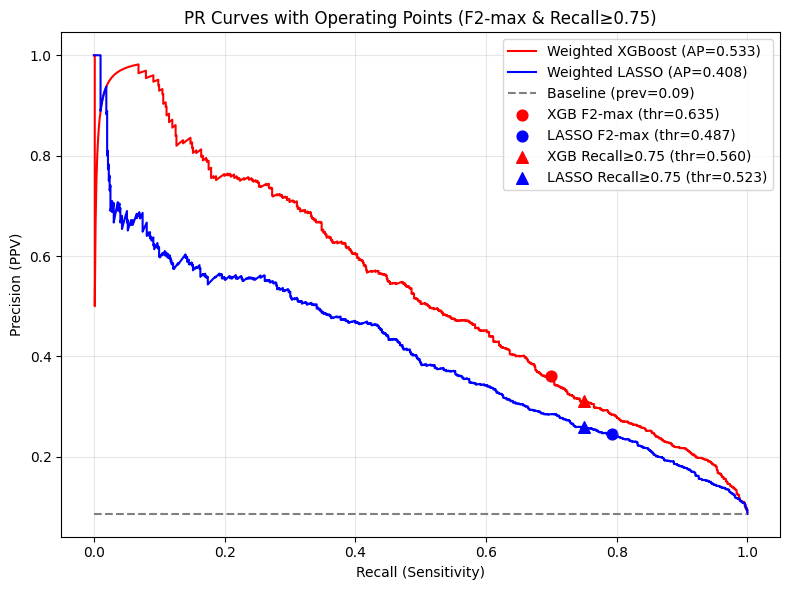

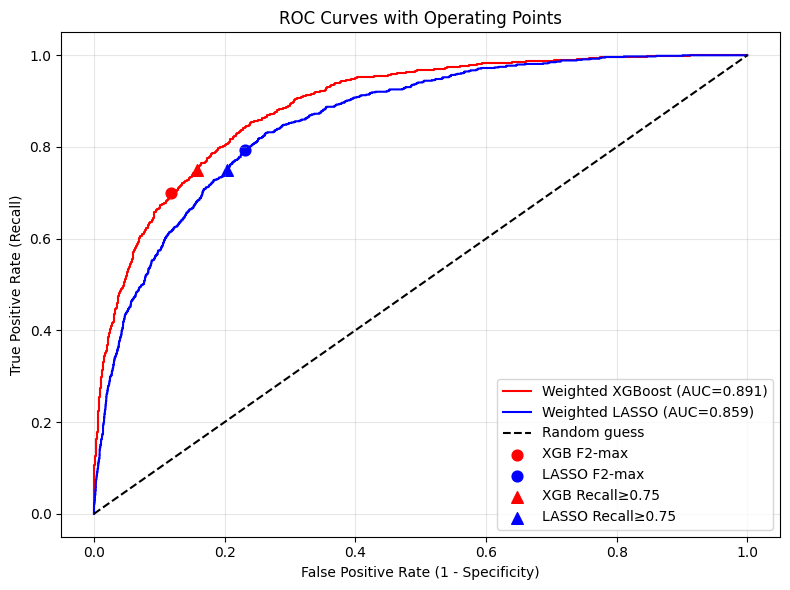


== F2-max operating points ==
XGB (F2-max): thr=0.6350 | Recall=0.699 | Precision=0.361 | FPR=0.117 | TPR=0.699
LASSO (F2-max): thr=0.4872 | Recall=0.793 | Precision=0.245 | FPR=0.231 | TPR=0.793

== Target-recall operating points ==
XGB (Recall≥0.75): thr=0.5596 | Recall=0.750 | Precision=0.310 | FPR=0.158 | TPR=0.750
LASSO (Recall≥0.75): thr=0.5232 | Recall=0.750 | Precision=0.259 | FPR=0.203 | TPR=0.750


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score
)

# Assumes you already have:
# y_test
# y_proba_weighted    # weighted XGBoost scores
# y_proba_lasso_w     # weighted LASSO scores

# ---------------------------
# Helpers
# ---------------------------
def pick_threshold_max_fbeta(precision, recall, thresholds, beta=2.0):
    """
    Given PR arrays (from precision_recall_curve), return threshold that maximizes F-beta.
    Note: precision/recall have len = len(thresholds)+1; the i-th threshold maps to precision[i+1], recall[i+1].
    """
    # avoid division by zero
    eps = 1e-12
    fbeta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + eps)
    # the first element of precision/recall corresponds to a threshold below min(scores); skip index 0 for mapping
    fbeta_valid = fbeta[1:]
    idx = int(np.nanargmax(fbeta_valid))
    thr = thresholds[idx]
    return thr, fbeta[1+idx]

def pick_threshold_for_target_recall(recall, thresholds, target_recall=0.75):
    """
    Find the *lowest* threshold achieving recall >= target_recall.
    recall has length len(thresholds)+1, decreasing with threshold.
    We map recall[i+1] to thresholds[i].
    """
    # scan from high recall to low (recall is typically non-increasing)
    indices = np.where(recall[1:] >= target_recall)[0]
    if len(indices) == 0:
        # not achievable: return smallest threshold (max recall) as best effort
        return thresholds[0], recall[1]
    i = indices[-1]  # lowest threshold that still meets target recall
    return thresholds[i], recall[i+1]

def operating_point_on_pr(y_true, y_score, thr):
    """Return (recall, precision) at a given threshold."""
    y_pred = (y_score >= thr).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return recall, precision

def operating_point_on_roc(y_true, y_score, thr):
    """Return (FPR, TPR) at a given threshold."""
    y_pred = (y_score >= thr).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # recall
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return fpr, tpr

# ---------------------------
# Curves + AUC/AP
# ---------------------------
# Weighted XGBoost
prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(y_test, y_proba_weighted)
ap_xgb = average_precision_score(y_test, y_proba_weighted)
fpr_xgb, tpr_xgb, roc_thr_xgb = roc_curve(y_test, y_proba_weighted)
auc_xgb = roc_auc_score(y_test, y_proba_weighted)

# Weighted LASSO
prec_lasso, rec_lasso, thr_lasso = precision_recall_curve(y_test, y_proba_lasso_w)
ap_lasso = average_precision_score(y_test, y_proba_lasso_w)
fpr_lasso, tpr_lasso, roc_thr_lasso = roc_curve(y_test, y_proba_lasso_w)
auc_lasso = roc_auc_score(y_test, y_proba_lasso_w)

# ---------------------------
# Pick operating points
# ---------------------------
TARGET_RECALL = 0.75
BETA = 2.0

# XGB thresholds
thr_xgb_f2, f2_xgb = pick_threshold_max_fbeta(prec_xgb, rec_xgb, thr_xgb, beta=BETA)
thr_xgb_recall, rec_hit_xgb = pick_threshold_for_target_recall(rec_xgb, thr_xgb, target_recall=TARGET_RECALL)

# LASSO thresholds
thr_ls_f2, f2_ls = pick_threshold_max_fbeta(prec_lasso, rec_lasso, thr_lasso, beta=BETA)
thr_ls_recall, rec_hit_ls = pick_threshold_for_target_recall(rec_lasso, thr_lasso, target_recall=TARGET_RECALL)

# Points on PR at chosen thresholds
rec_xgb_f2, prec_xgb_f2 = operating_point_on_pr(y_test, y_proba_weighted, thr_xgb_f2)
rec_xgb_r,  prec_xgb_r  = operating_point_on_pr(y_test, y_proba_weighted, thr_xgb_recall)

rec_ls_f2, prec_ls_f2 = operating_point_on_pr(y_test, y_proba_lasso_w, thr_ls_f2)
rec_ls_r,  prec_ls_r  = operating_point_on_pr(y_test, y_proba_lasso_w, thr_ls_recall)

# Points on ROC at chosen thresholds
fpr_xgb_f2, tpr_xgb_f2 = operating_point_on_roc(y_test, y_proba_weighted, thr_xgb_f2)
fpr_xgb_r,  tpr_xgb_r  = operating_point_on_roc(y_test, y_proba_weighted, thr_xgb_recall)

fpr_ls_f2, tpr_ls_f2 = operating_point_on_roc(y_test, y_proba_lasso_w, thr_ls_f2)
fpr_ls_r,  tpr_ls_r  = operating_point_on_roc(y_test, y_proba_lasso_w, thr_ls_recall)

# ---------------------------
# Plot PR with markers
# ---------------------------
baseline = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(rec_xgb, prec_xgb, label=f'Weighted XGBoost (AP={ap_xgb:.3f})', color='red')
plt.plot(rec_lasso, prec_lasso, label=f'Weighted LASSO (AP={ap_lasso:.3f})', color='blue')
plt.hlines(baseline, 0, 1, colors='gray', linestyles='dashed', label=f'Baseline (prev={baseline:.2f})')

# Mark F2-max points
plt.scatter(rec_xgb_f2, prec_xgb_f2, color='red', marker='o', s=60, label=f'XGB F2-max (thr={thr_xgb_f2:.3f})')
plt.scatter(rec_ls_f2,  prec_ls_f2,  color='blue', marker='o', s=60, label=f'LASSO F2-max (thr={thr_ls_f2:.3f})')

# Mark target-recall points
plt.scatter(rec_xgb_r, prec_xgb_r, color='red', marker='^', s=70, label=f'XGB Recall≥{TARGET_RECALL:.2f} (thr={thr_xgb_recall:.3f})')
plt.scatter(rec_ls_r,  prec_ls_r,  color='blue', marker='^', s=70, label=f'LASSO Recall≥{TARGET_RECALL:.2f} (thr={thr_ls_recall:.3f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (PPV)')
plt.title(f'PR Curves with Operating Points (F{BETA:.0f}-max & Recall≥{TARGET_RECALL:.2f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot ROC with markers
# ---------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'Weighted XGBoost (AUC={auc_xgb:.3f})', color='red')
plt.plot(fpr_lasso, tpr_lasso, label=f'Weighted LASSO (AUC={auc_lasso:.3f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')

# Mark F2-max points
plt.scatter(fpr_xgb_f2, tpr_xgb_f2, color='red', marker='o', s=60, label='XGB F2-max')
plt.scatter(fpr_ls_f2,  tpr_ls_f2,  color='blue', marker='o', s=60, label='LASSO F2-max')

# Mark target recall points
plt.scatter(fpr_xgb_r, tpr_xgb_r, color='red', marker='^', s=70, label=f'XGB Recall≥{TARGET_RECALL:.2f}')
plt.scatter(fpr_ls_r,  tpr_ls_r,  color='blue', marker='^', s=70, label=f'LASSO Recall≥{TARGET_RECALL:.2f}')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves with Operating Points')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# Print a compact summary
# ---------------------------
def summarize_point(name, thr, rec, prec, fpr, tpr):
    print(f"{name}: thr={thr:.4f} | Recall={rec:.3f} | Precision={prec:.3f} | FPR={fpr:.3f} | TPR={tpr:.3f}")

print("\n== F2-max operating points ==")
summarize_point("XGB (F2-max)", thr_xgb_f2, rec_xgb_f2, prec_xgb_f2, fpr_xgb_f2, tpr_xgb_f2)
summarize_point("LASSO (F2-max)", thr_ls_f2, rec_ls_f2, prec_ls_f2, fpr_ls_f2, tpr_ls_f2)

print("\n== Target-recall operating points ==")
summarize_point(f"XGB (Recall≥{TARGET_RECALL:.2f})", thr_xgb_recall, rec_xgb_r, prec_xgb_r, fpr_xgb_r, tpr_xgb_r)
summarize_point(f"LASSO (Recall≥{TARGET_RECALL:.2f})", thr_ls_recall, rec_ls_r, prec_ls_r, fpr_ls_r, tpr_ls_r)


**Interpretation using SHAP values**

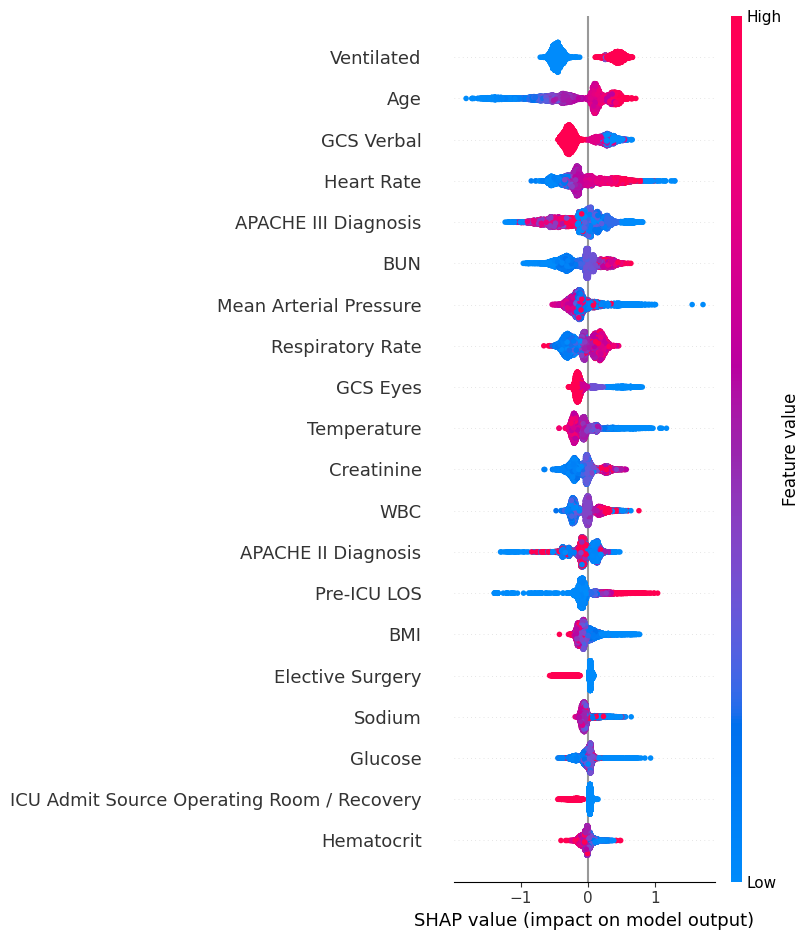

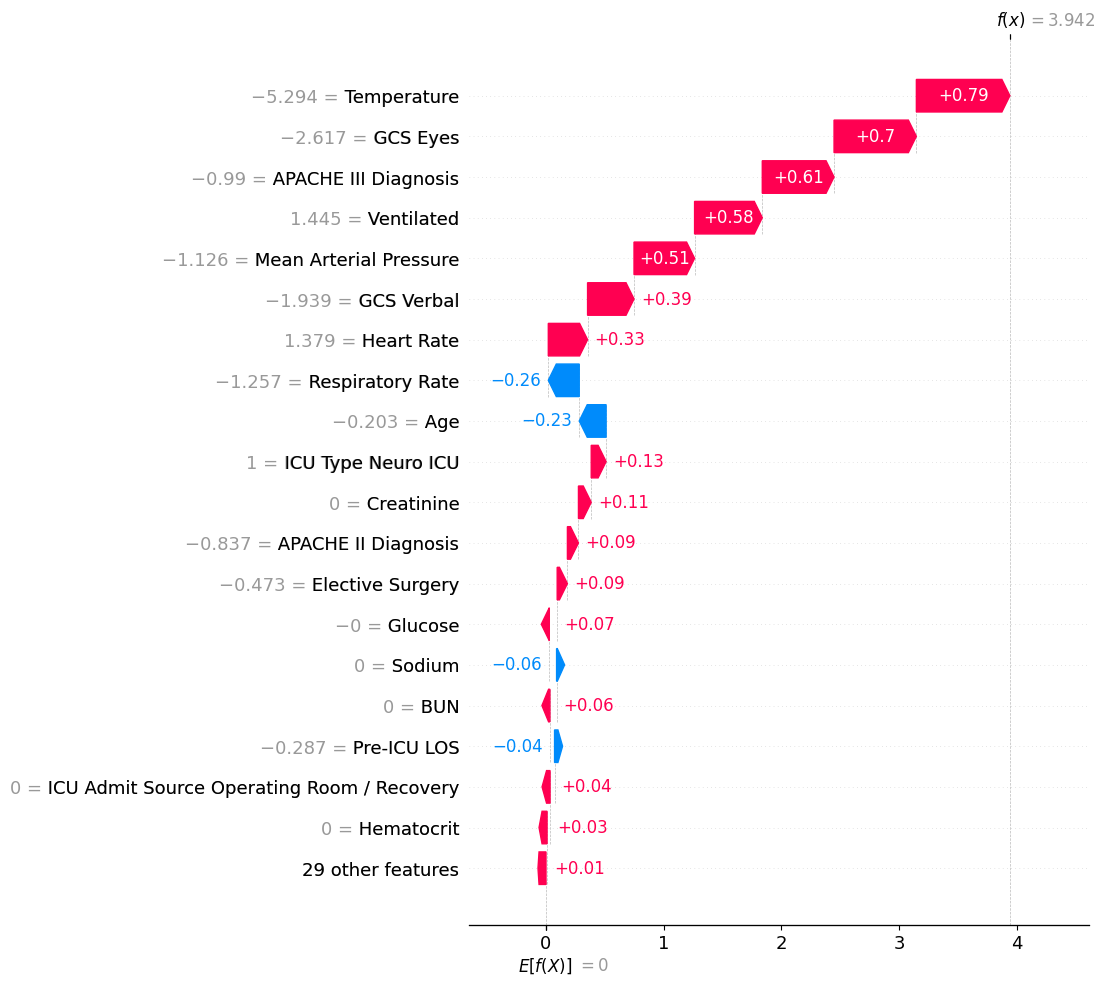

In [ ]:
import re
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd

# 1) Get feature names from the ColumnTransformer and clean them
raw_feature_names = preprocessor.get_feature_names_out()

def clean_names(names):
    cleaned = []
    for s in names:
        # Remove transformer prefixes like "num__", "bin__", "cat__" (double underscore pattern)
        s = re.sub(r'^(num|bin|cat)__', '', s)
        # Optional: make OHE features clearer, e.g., "ICU Type_Emergency" -> "ICU Type = Emergency"
        s = s.replace('_', ' ')           # turn underscores into spaces
        s = s.replace(' = ', '=')         # tidy spaces around equals if any
        s = s.replace('  ', ' ')          # collapse double spaces
        s = s.replace(' ', ' ')           # no-op; keep for clarity
        s = s.replace('  ', ' ')
        s = s.replace(' =', ' =')         # keep equals tight
        if ' ' in s and '=' not in s and '__' not in s:
            # leave continuous names untouched
            pass
        # For OHE names that still look like "Feature Category"
        # you could choose to add an equals sign if you want:
        # if ' ' in s and '=' not in s:
        #     parts = s.split(' ', 1)
        #     s = f"{parts[0]} = {parts[1]}"
        cleaned.append(s)
    return cleaned

feature_names = clean_names(raw_feature_names)

# 2) Build a DataFrame with cleaned names for the test matrix
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# 3) Use the WEIGHTED XGBoost model for SHAP
#    (best_model_weighted is your fitted XGBClassifier with scale_pos_weight)
# TreeExplainer is optimal for tree models
explainer = shap.TreeExplainer(best_model_weighted)

# For speed you can sample the background; here we just compute on all test rows
shap_values = explainer(X_test_df)

# 4) Global importance summary
shap.summary_plot(shap_values, X_test_df, show=True)

# 5) Single prediction explanation (use any index you want)
i = 0
shap.plots.waterfall(shap_values[i], max_display=20)
